In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import pandas as pd
import os, glob, json
from pathlib import Path


In [6]:
# Load actual data from JSON files
json_files = list(Path('results').glob('results_*.json'))

if len(json_files) == 0:
    # Use mock data if no JSON files found
    print('No JSON files found, using mock data for demonstration...')
    sizes = ['1M', '10M', '100M', '1B']
    size_multipliers = {
        '1M': 1,
        '10M': 2,
        '100M': 4,
        '1B': 8,
    }  # Larger index = longer runtime
    nqueries_list = [1, 4402]
    nprobes = [1, 2, 4, 8, 16, 32, 64, 128, 256]

    mock_results = []
    rng = np.random.default_rng(42)
    for size in sizes:
        for n_queries in nqueries_list:
            for nprobe in nprobes:
                # Base time that increases with nprobe (higher nprobe = slower but more accurate)
                # and increases with index size
                base_time = 0.1 * (nprobe / 256) * size_multipliers[size]
                query_scaling = n_queries / 1000 if n_queries > 1 else 0.01
                mean_time = base_time * query_scaling * rng.uniform(0.8, 1.2)
                std_time = mean_time * rng.uniform(0.05, 0.15)
                mock_results.append(
                    {
                        'index_path': f'speed-test-{size}-index.bin',
                        'nprobe': nprobe,
                        'n_queries': n_queries,
                        'k': 20,
                        'embedding_dim': 2560,
                        'mean_search_time': mean_time,
                        'std_search_time': std_time,
                        'size': size,
                    }
                )
    df = pd.DataFrame(mock_results)
else:
    # Load actual JSON data
    print(f'Found {len(json_files)} JSON files, loading actual data...')
    results = []
    for json_file in json_files:
        with open(json_file, 'r') as f:
            data = json.load(f)
            # Extract size from filename
            # format: results_size_1M_nprobe_16_nq_4402.json
            filename = json_file.name
            size = filename.split('_')[2]
            data['size'] = size
            results.append(data)
    df = pd.DataFrame(results)

print(f'Loaded {len(df)} data points')
df.head()


Found 72 JSON files, loading actual data...
Loaded 72 data points


,index_path,nprobe,k,n_queries,embedding_dim,mean_search_time,std_search_time,size
0,faiss_indices/speed-test-1M-index.bin,16,20,4402,2560,2.707038,1.249045,1M
1,faiss_indices/speed-test-10M-index.bin,64,20,1,2560,0.045725,0.005416,10M
2,faiss_indices/speed-test-1M-index.bin,256,20,4402,2560,6.203725,0.389060,1M
3,faiss_indices/speed-test-1B-index.bin,8,20,1,2560,0.061629,0.004881,1B
4,faiss_indices/speed-test-1B-index.bin,256,20,4402,2560,79.202278,0.987049,1B


In [7]:
df

,index_path,nprobe,k,n_queries,embedding_dim,mean_search_time,std_search_time,size
0,faiss_indices/speed-test-1M-index.bin,16,20,4402,2560,2.707038,1.249045,1M
1,faiss_indices/speed-test-10M-index.bin,64,20,1,2560,0.045725,0.005416,10M
2,faiss_indices/speed-test-1M-index.bin,256,20,4402,2560,6.203725,0.389060,1M
3,faiss_indices/speed-test-1B-index.bin,8,20,1,2560,0.061629,0.004881,1B
4,faiss_indices/speed-test-1B-index.bin,256,20,4402,2560,79.202278,0.987049,1B
...,...,...,...,...,...,...,...,...
67,faiss_indices/speed-test-1B-index.bin,8,20,4402,2560,6.063982,0.781708,1B
68,faiss_indices/speed-test-10M-index.bin,4,20,4402,2560,0.999537,0.642569,10M
69,faiss_indices/speed-test-10M-index.bin,4,20,1,2560,0.007653,0.006653,10M
70,faiss_indices/speed-test-1M-index.bin,256,20,1,2560,0.032000,0.004793,1M


In [49]:
def plot_search_time_vs_nprobe(
    df, n_queries_val, save_path=None, figsize=(10, 7), exclude_nprobes=None
):
    """
    Plot mean search time vs. nprobe for a specific n_queries value.

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the benchmark results
    n_queries_val : int
        The n_queries value to filter and plot
    save_path : str, optional
        Path to save the plot as PDF. If None, plot is not saved.
    figsize : tuple, optional
        Figure size (width, height) in inches
    exclude_nprobes : list, optional
        List of nprobe values to exclude from the plot (e.g., [2, 4] to avoid crowding)
    """
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=figsize)

    # Filter data for this n_queries value
    df_filtered = df[df['n_queries'] == n_queries_val]

    # Exclude specified nprobe values if provided
    if exclude_nprobes is not None:
        df_filtered = df_filtered[~df_filtered['nprobe'].isin(exclude_nprobes)]
        print(f'Excluding nprobe values: {exclude_nprobes}')

    if df_filtered.empty:
        print(f'No data found for n_queries = {n_queries_val}')
        return

    annotation_offset = (
        df_filtered['mean_search_time'].max() * 0.02
    )  # Dynamic offset

    # Define the order of index sizes and color palette
    size_order = ['1M', '10M', '100M', '1B']
    colors = sns.color_palette('viridis', len(size_order))[
        ::-1
    ]  # viridis palette reversed (light to dark as size increases)

    for i, size in enumerate(size_order):
        if size not in df_filtered['size'].values:
            continue  # Skip if this size is not in the data

        group = df_filtered[df_filtered['size'] == size]
        # Sort by nprobe
        group = group.sort_values('nprobe')
        label = size
        color = colors[i]

        scatter = sns.scatterplot(
            x=group['nprobe'],
            y=group['mean_search_time'],
            s=100,
            edgecolor='black',
            color=color,
            label=label,
        )
        plt.plot(
            group['nprobe'],
            group['mean_search_time'],
            linestyle='-',
            marker='',
            color=color,
            alpha=0.7,
        )

    # Use log scale for y-axis
    # plt.yscale('log')

    # Limit the number of y-ticks to a maximum of 7
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=7))

    # Format y-axis labels to two decimal places
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    # Use log scale for x-axis but show actual nprobe values as tick labels
    # plt.xscale('log', base=2)
    nprobe_values = sorted(df_filtered['nprobe'].unique())
    plt.xticks(nprobe_values, [str(x) for x in nprobe_values])

    # Labels and title
    plt.xlabel('nprobe', fontsize=16)
    plt.ylabel('Mean Search Time (s)', fontsize=16)
    plt.title(
        f'IVF Search: Mean Search Time vs. nprobe (n_queries = {n_queries_val})',
        fontsize=18,
    )

    # Increase tick label font size
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    # Set the legend location with reversed order and title
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(
        handles[::-1],
        labels[::-1],
        loc='upper left',
        title='Index Size',
        fontsize=14,
        title_fontsize=14,
    )

    # Adjust grid line appearance (lighter)
    plt.grid(True, linewidth=0.5, alpha=0.4)

    plt.tight_layout()

    # Save the plot as a high-resolution PDF if path provided
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f'Plot saved to: {save_path}')

    plt.show()


Excluding nprobe values: [2, 4]
Plot saved to: figures/ivf_search_time_vs_nprobe_nq_1.png


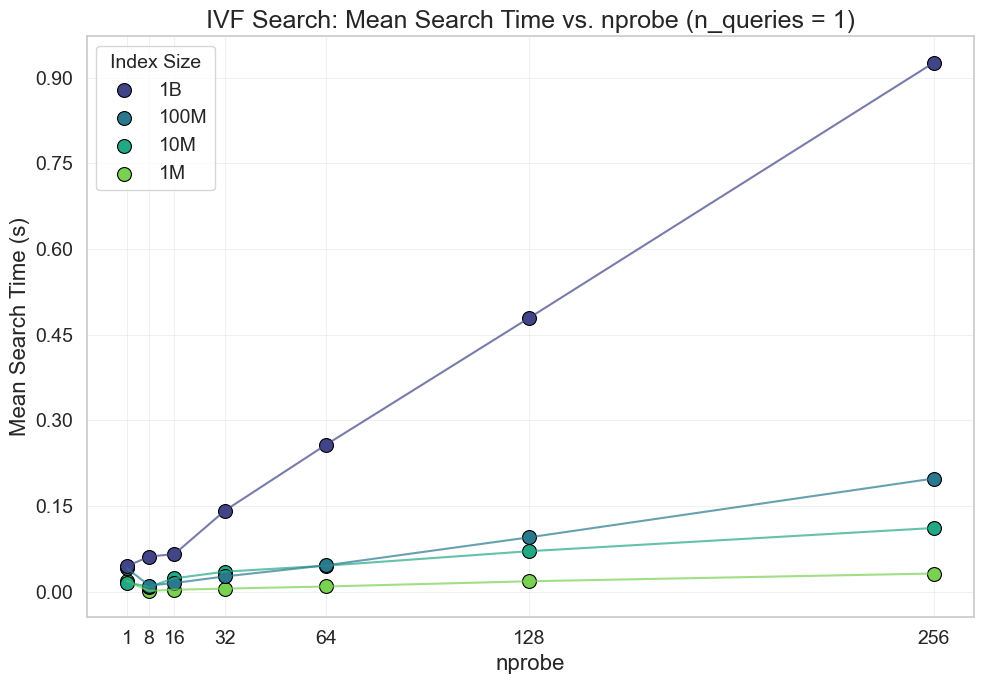

Excluding nprobe values: [2, 4]
Plot saved to: figures/ivf_search_time_vs_nprobe_nq_4402.png


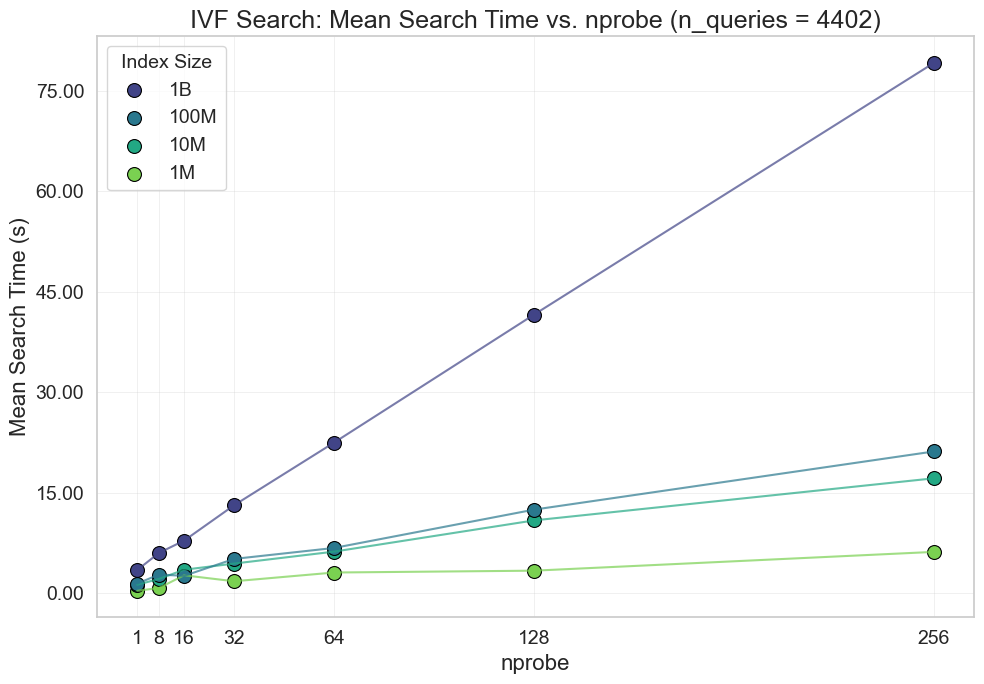

In [50]:
# Generate plots for each n_queries value
for n_queries_val in sorted(df['n_queries'].unique()):
    # Optional: save each plot to PDF
    save_path = f'figures/ivf_search_time_vs_nprobe_nq_{n_queries_val}.png'
    # save_path = None  # Set to None to not save

    # Exclude nprobe values 2 and 4 to avoid crowding the plots
    plot_search_time_vs_nprobe(
        df, n_queries_val, save_path=save_path, exclude_nprobes=[2, 4]
    )


In [ ]:
# Alternative: Generate plots without excluding any nprobe values
# Uncomment the following lines if you want to plot all nprobe values:

# for n_queries_val in sorted(df['n_queries'].unique()):
#     save_path = None  # Set to None to not save
#     plot_search_time_vs_nprobe(df, n_queries_val, save_path=save_path, exclude_nprobes=None)

# Or exclude different nprobe values:
# for n_queries_val in sorted(df['n_queries'].unique()):
#     save_path = None  # Set to None to not save
#     plot_search_time_vs_nprobe(df, n_queries_val, save_path=save_path, exclude_nprobes=[1, 256])


# Exact Search Speed Analysis

This section analyzes the performance of exact binary search, plotting search time vs. k (number of nearest neighbors) instead of nprobe.

In [42]:
# Load exact search data from JSON files
exact_json_files = list(Path('results').glob('results_exact_*.json'))

if len(exact_json_files) == 0:
    # Use mock data if no JSON files found
    print(
        'No exact search JSON files found, using mock data for demonstration...'
    )
    sizes = ['1M', '10M', '100M', '1B']
    size_multipliers = {
        '1M': 1,
        '10M': 2,
        '100M': 4,
        '1B': 8,
    }  # Larger index = longer runtime
    nqueries_list = [1, 4402]
    k_values = [1, 100, 1000]

    mock_exact_results = []
    rng = np.random.default_rng(42)
    for size in sizes:
        for n_queries in nqueries_list:
            for k in k_values:
                # Base time that increases with k (higher k = more neighbors to find)
                # and increases with index size
                base_time = 0.05 * (k / 1000) * size_multipliers[size]
                query_scaling = n_queries / 1000 if n_queries > 1 else 0.01
                mean_time = base_time * query_scaling * rng.uniform(0.8, 1.2)
                std_time = mean_time * rng.uniform(0.05, 0.15)
                mock_exact_results.append(
                    {
                        'index_path': f'speed-test-{size}-exact-index.bin',
                        'k': k,
                        'n_queries': n_queries,
                        'embedding_dim': 2560,
                        'mean_search_time': mean_time,
                        'std_search_time': std_time,
                        'index_type': 'exact',
                        'size': size,
                    }
                )
    df_exact = pd.DataFrame(mock_exact_results)
else:
    # Load actual JSON data
    print(
        f'Found {len(exact_json_files)} exact search JSON files, loading actual data...'
    )
    exact_results = []
    for json_file in exact_json_files:
        with open(json_file, 'r') as f:
            data = json.load(f)
            # Extract size from filename
            # format: results_exact_size_1B_k_100_nq_4402.json
            filename = json_file.name
            size = filename.split('_')[3]  # size is at index 3
            data['size'] = size
            exact_results.append(data)
    df_exact = pd.DataFrame(exact_results)

print(f'Loaded {len(df_exact)} exact search data points')
df_exact.head()


No exact search JSON files found, using mock data for demonstration...
Loaded 24 exact search data points


,index_path,k,n_queries,embedding_dim,mean_search_time,std_search_time,index_type,size
0,speed-test-1M-exact-index.bin,1,1,2560,5.547912e-07,5.208815e-08,exact,1M
1,speed-test-1M-exact-index.bin,100,1,2560,5.717196e-05,6.845588e-06,exact,1M
2,speed-test-1M-exact-index.bin,1000,1,2560,4.188355e-04,6.180430e-05,exact,1M
3,speed-test-1M-exact-index.bin,1,4402,2560,2.430907e-04,3.126303e-05,exact,1M
4,speed-test-1M-exact-index.bin,100,4402,2560,1.873591e-02,1.780635e-03,exact,1M


In [46]:
def plot_search_time_vs_k(df, n_queries_val, save_path=None, figsize=(10, 7)):
    """
    Plot mean search time vs. k for a specific n_queries value (exact search).

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the benchmark results
    n_queries_val : int
        The n_queries value to filter and plot
    save_path : str, optional
        Path to save the plot as PDF. If None, plot is not saved.
    figsize : tuple, optional
        Figure size (width, height) in inches
    """
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=figsize)

    # Filter data for this n_queries value
    df_filtered = df[df['n_queries'] == n_queries_val]

    if df_filtered.empty:
        print(f'No data found for n_queries = {n_queries_val}')
        return

    annotation_offset = (
        df_filtered['mean_search_time'].max() * 0.02
    )  # Dynamic offset

    # Define the order of index sizes and color palette
    size_order = ['1M', '10M', '100M', '1B']
    colors = sns.color_palette('viridis', len(size_order))[
        ::-1
    ]  # viridis palette reversed (light to dark as size increases)

    for i, size in enumerate(size_order):
        if size not in df_filtered['size'].values:
            continue  # Skip if this size is not in the data

        group = df_filtered[df_filtered['size'] == size]
        # Sort by k
        group = group.sort_values('k')
        label = size
        color = colors[i]

        scatter = sns.scatterplot(
            x=group['k'],
            y=group['mean_search_time'],
            s=100,
            edgecolor='black',
            color=color,
            label=label,
        )
        plt.plot(
            group['k'],
            group['mean_search_time'],
            linestyle='-',
            marker='',
            color=color,
            alpha=0.7,
        )

    # Limit the number of y-ticks to a maximum of 7
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=7))

    # Format y-axis labels to two decimal places
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    # Use log scale for x-axis but show actual k values as tick labels
    # plt.xscale('log', base=10)
    k_values = sorted(df_filtered['k'].unique())
    plt.xticks(k_values, [str(x) for x in k_values])

    # Labels and title
    plt.xlabel('k (Number of Nearest Neighbors)', fontsize=16)
    plt.ylabel('Mean Search Time (s)', fontsize=16)
    plt.title(
        f'Exact Search: Mean Search Time vs. k (n_queries = {n_queries_val})',
        fontsize=18,
    )

    # Increase tick label font size
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    # Set the legend location with reversed order and title
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(
        handles[::-1],
        labels[::-1],
        loc='upper left',
        title='Index Size',
        fontsize=14,
        title_fontsize=14,
    )

    # Adjust grid line appearance (lighter)
    plt.grid(True, linewidth=0.5, alpha=0.4)

    plt.tight_layout()

    # Save the plot as a high-resolution PDF if path provided
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f'Plot saved to: {save_path}')

    plt.show()


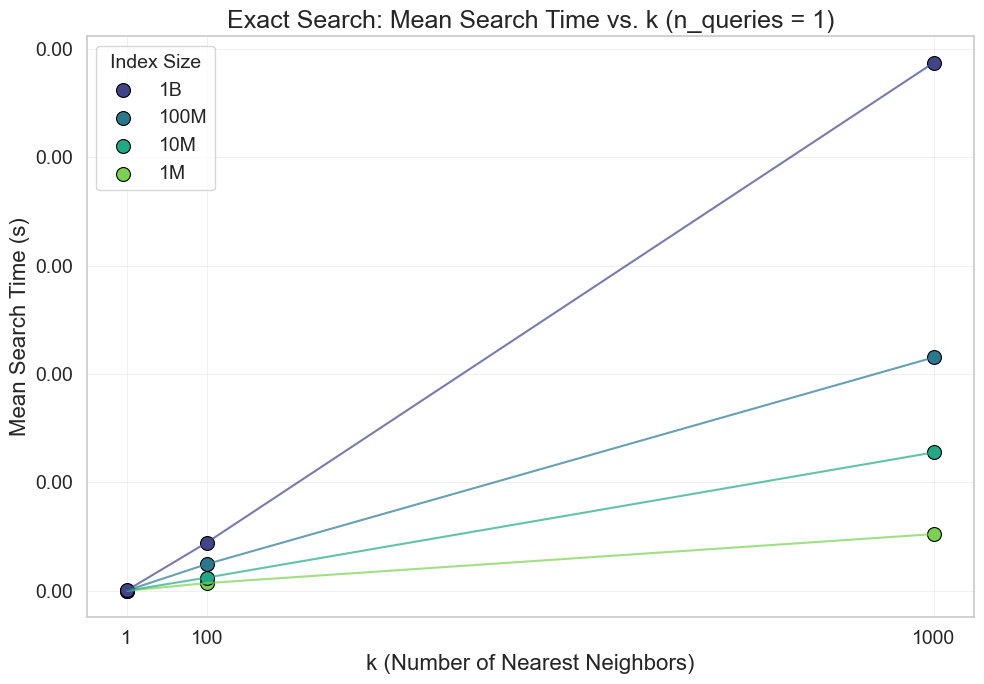

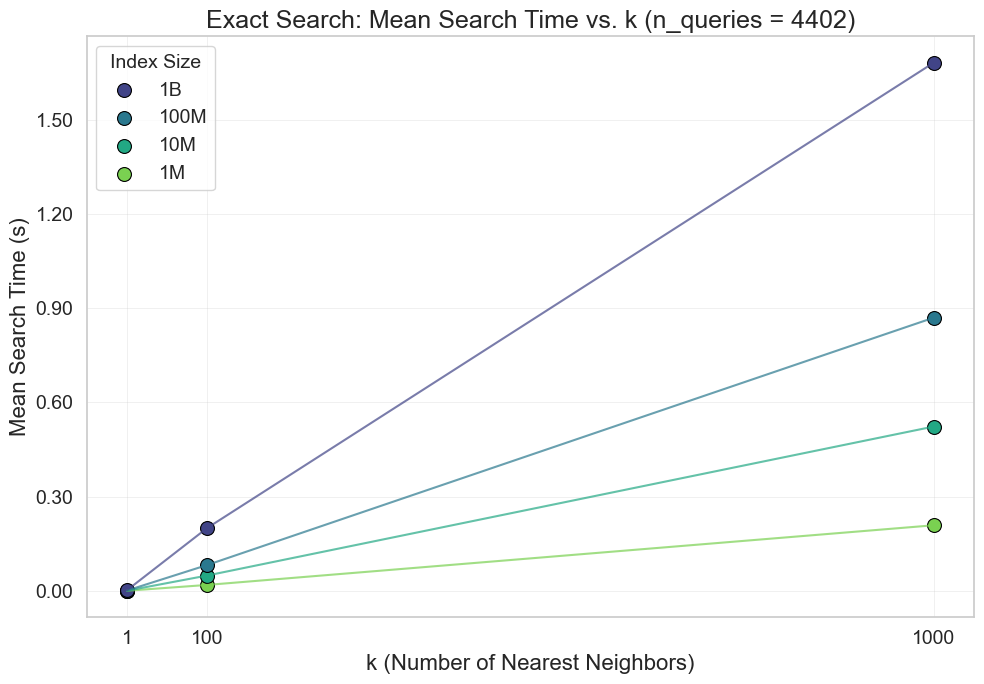

In [44]:
# Generate plots for each n_queries value for exact search
for n_queries_val in sorted(df_exact['n_queries'].unique()):
    # Optional: save each plot to PDF
    # save_path = f'exact_search_time_vs_k_nq_{n_queries_val}.pdf'
    save_path = None  # Set to None to not save

    plot_search_time_vs_k(df_exact, n_queries_val, save_path=save_path)


## Storage Footprint Comparison: IVF vs Exact Search



In [19]:
# Output from du -h
# 30G	speed-test-100M-exact-index.bin
# 31G	speed-test-100M-index.bin
# 3.0G	speed-test-10M-exact-index.bin
# 3.1G	speed-test-10M-index.bin
# 299G	speed-test-1B-exact-index.bin
# 306G	speed-test-1B-index.bin
# 306M	speed-test-1M-exact-index.bin
# 314M	speed-test-1M-index.bin

# Storage footprint data (manually input values in GB)
# You can update these values with actual measurements
storage_data = {
    '1M': {'exact': 0.306, 'ivf': 0.314},
    '10M': {'exact': 3.0, 'ivf': 3.1},
    '100M': {'exact': 30.0, 'ivf': 31.0},
    '1B': {'exact': 299.0, 'ivf': 306.0},
}

print('Storage footprint data loaded:')
for size, values in storage_data.items():
    print(
        f'  {size}: Exact = {values["exact"]:.1f} GB, IVF = {values["ivf"]:.1f} GB'
    )


Storage footprint data loaded:
  1M: Exact = 0.3 GB, IVF = 0.3 GB
  10M: Exact = 3.0 GB, IVF = 3.1 GB
  100M: Exact = 30.0 GB, IVF = 31.0 GB
  1B: Exact = 299.0 GB, IVF = 306.0 GB


Plot saved to figures/storage_footprint_comparison.pdf


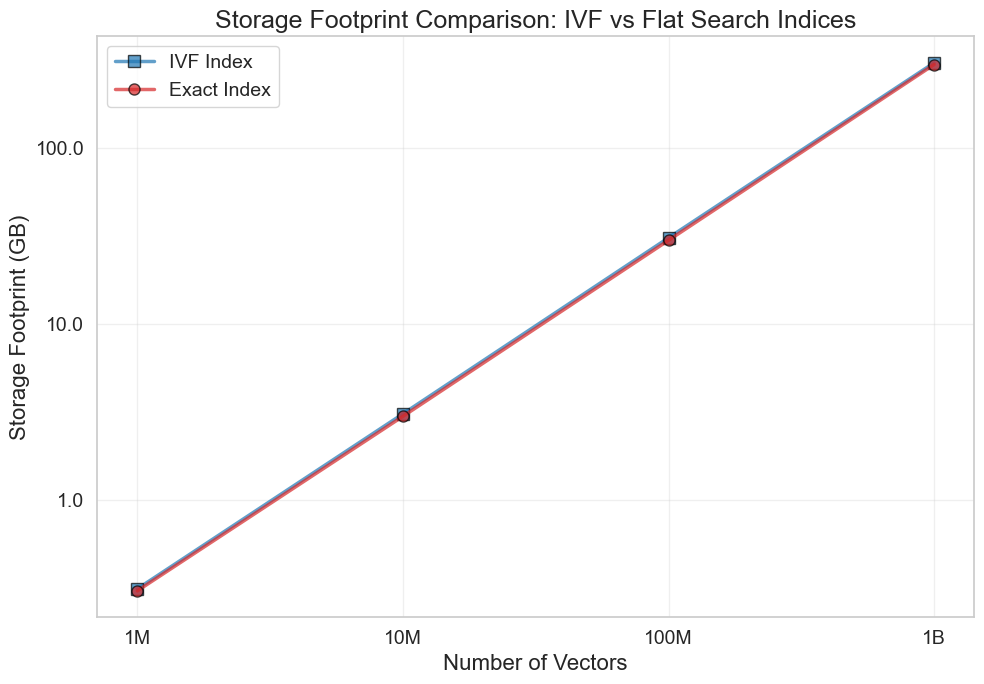


Storage Footprint Summary:
  1M: Flat =    0.3 GB, IVF =    0.3 GB
 10M: Flat =    3.0 GB, IVF =    3.1 GB
100M: Flat =   30.0 GB, IVF =   31.0 GB
  1B: Flat =  299.0 GB, IVF =  306.0 GB


In [34]:
def plot_storage_footprint_comparison(save_path=None, figsize=(10, 7)):
    """
    Plot storage footprint comparison between IVF and exact search indices.

    Parameters:
    -----------
    save_path : str, optional
        Path to save the plot as PDF. If None, plot is not saved.
    figsize : tuple, optional
        Figure size (width, height) in inches
    """
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=figsize)

    # Get storage data from the manually input values
    labels = ['1M', '10M', '100M', '1B']
    exact_storage = [storage_data[label]['exact'] for label in labels]
    ivf_storage = [storage_data[label]['ivf'] for label in labels]

    # Convert to numpy arrays
    exact_storage = np.array(exact_storage)
    ivf_storage = np.array(ivf_storage)

    # Create labels for x-axis
    labels = ['1M', '10M', '100M', '1B']

    # Define contrasting colors for better visibility
    color_exact = '#d62728'  # Red
    color_ivf = '#1f77b4'  # Blue

    # Plot both lines with transparency
    plt.plot(
        labels,
        ivf_storage,
        marker='s',
        linewidth=2.5,
        markersize=8,
        color=color_ivf,
        label='IVF Index',
        markeredgecolor='black',
        markeredgewidth=1,
        alpha=0.7,
    )

    plt.plot(
        labels,
        exact_storage,
        marker='o',
        linewidth=2.5,
        markersize=8,
        color=color_exact,
        label='Exact Index',
        markeredgecolor='black',
        markeredgewidth=1,
        alpha=0.7,
    )

    # Formatting
    plt.xlabel('Number of Vectors', fontsize=16)
    plt.ylabel('Storage Footprint (GB)', fontsize=16)
    plt.title(
        'Storage Footprint Comparison: IVF vs Flat Search Indices',
        fontsize=18,
    )

    # Use log scale for y-axis since storage grows linearly with npoints
    plt.yscale('log')

    # Format y-axis labels
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # Increase tick label font size
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    # Add grid for better readability
    plt.grid(True, alpha=0.3)

    # Legend
    plt.legend(loc='upper left', fontsize=14)

    # Tight layout
    plt.tight_layout()

    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f'Plot saved to {save_path}')

    plt.show()

    # Print storage values for reference
    print('\nStorage Footprint Summary:')
    print('=' * 40)
    for i, label in enumerate(labels):
        print(
            f'{label:>4}: Flat = {exact_storage[i]:6.1f} GB, IVF = {ivf_storage[i]:6.1f} GB'
        )


# Create the plot
plot_storage_footprint_comparison(
    save_path='figures/storage_footprint_comparison.pdf'
)
